First rows:
        Date  Temperature   Humidity
0 2022-01-01    19.363503  53.166158
1 2022-01-02    33.767858  87.671434
2 2022-01-03    28.299849  84.321039
3 2022-01-04    24.966462  41.747468
4 2022-01-05    13.900466  34.161678

Temperature statistics:
Mean: 22.28867570535238
Median: 22.783559971523445
Standard deviation: 7.276764988108157

Humidity statistics:
Mean: 59.67850785931096
Median: 59.52697758477229
Standard deviation: 18.038244826081275

Highest temperature date:
2022-09-19 00:00:00

Highest humidity date:
2022-06-16 00:00:00

First 10 rows with rolling averages:
        Date  Temperature   Humidity  Temperature_7day_avg  Humidity_7day_avg
0 2022-01-01    19.363503  53.166158                   NaN                NaN
1 2022-01-02    33.767858  87.671434                   NaN                NaN
2 2022-01-03    28.299849  84.321039                   NaN                NaN
3 2022-01-04    24.966462  41.747468                   NaN                NaN
4 2022-01-05    13.900

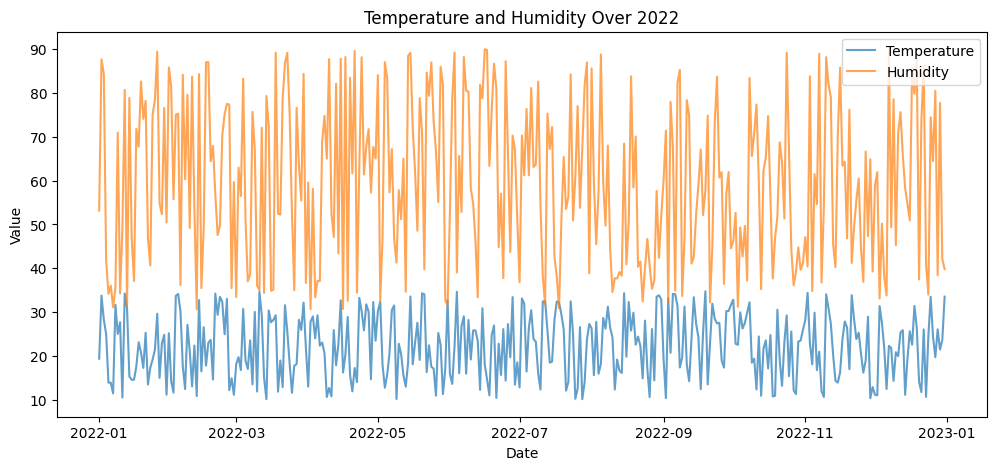

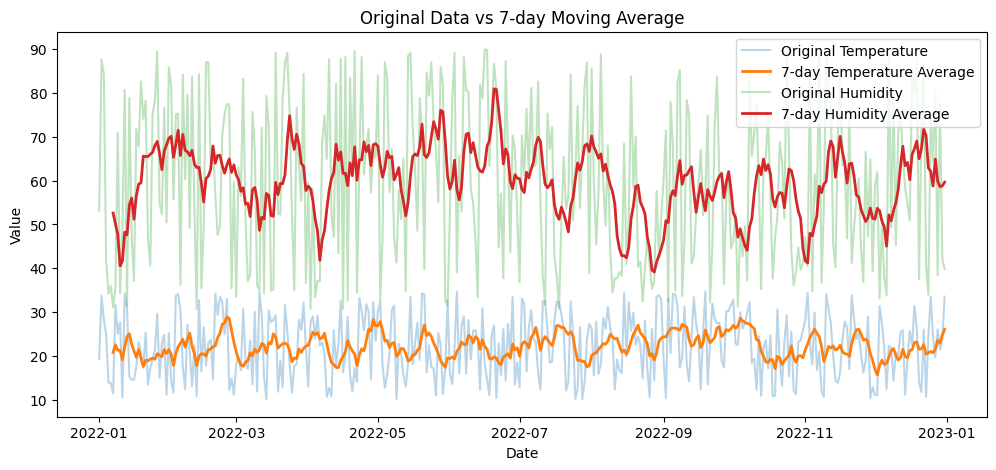

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make random results reproducible
np.random.seed(42)

# 1. Create the time series dataset
dates = pd.date_range(start="2022-01-01", end="2022-12-31", freq="D")

temperature = np.random.uniform(10, 35, size=len(dates))
humidity = np.random.uniform(30, 90, size=len(dates))

df = pd.DataFrame({
    "Date": dates,
    "Temperature": temperature,
    "Humidity": humidity
})

# 2. Basic analysis
print("First rows:")
print(df.head())

print("\nTemperature statistics:")
print("Mean:", df["Temperature"].mean())
print("Median:", df["Temperature"].median())
print("Standard deviation:", df["Temperature"].std())

print("\nHumidity statistics:")
print("Mean:", df["Humidity"].mean())
print("Median:", df["Humidity"].median())
print("Standard deviation:", df["Humidity"].std())

highest_temperature_index = df["Temperature"].idxmax()
highest_humidity_index = df["Humidity"].idxmax()

print("\nHighest temperature date:")
print(df.loc[highest_temperature_index, "Date"])

print("\nHighest humidity date:")
print(df.loc[highest_humidity_index, "Date"])

# 3. Rolling window / moving average
df["Temperature_7day_avg"] = df["Temperature"].rolling(window=7).mean()
df["Humidity_7day_avg"] = df["Humidity"].rolling(window=7).mean()

print("\nFirst 10 rows with rolling averages:")
print(df.head(10))

# 4. Bonus plots
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Temperature"], label="Temperature", alpha=0.7)
plt.plot(df["Date"], df["Humidity"], label="Humidity", alpha=0.7)
plt.title("Temperature and Humidity Over 2022")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Temperature"], label="Original Temperature", alpha=0.3)
plt.plot(df["Date"], df["Temperature_7day_avg"], label="7-day Temperature Average", linewidth=2)

plt.plot(df["Date"], df["Humidity"], label="Original Humidity", alpha=0.3)
plt.plot(df["Date"], df["Humidity_7day_avg"], label="7-day Humidity Average", linewidth=2)

plt.title("Original Data vs 7-day Moving Average")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()